# 1. Installing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

from sklearn.model_selection import train_test_split, StratifiedKFold

# Linear Model
from sklearn.linear_model import LogisticRegression # Linear classifier with probabilistic output

# Support Vector Machine (SVM)
from sklearn.svm import SVC # Kernel-based classifier for complex boundaries

# Decision Trees and Ensembles
from sklearn.tree import DecisionTreeClassifier # Basic decision tree
from sklearn.ensemble import RandomForestClassifier # Ensemble of decision trees using bagging

# Instance-based Learning
from sklearn.neighbors import KNeighborsClassifier # Memory-based approach

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# 2. Load the dataset

In [ ]:
df_raw = pd.read_csv("AIDS_Classification.csv")
df_raw.head()

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,...,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,...,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,...,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,...,1,3,0,0,0,504,353,870,782,0


In [ ]:
df_raw.shape

(2139, 23)

# 3. Data Summary

In [ ]:
df = df_raw.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      2139 non-null   int64  
 1   trt       2139 non-null   int64  
 2   age       2139 non-null   int64  
 3   wtkg      2139 non-null   float64
 4   hemo      2139 non-null   int64  
 5   homo      2139 non-null   int64  
 6   drugs     2139 non-null   int64  
 7   karnof    2139 non-null   int64  
 8   oprior    2139 non-null   int64  
 9   z30       2139 non-null   int64  
 10  preanti   2139 non-null   int64  
 11  race      2139 non-null   int64  
 12  gender    2139 non-null   int64  
 13  str2      2139 non-null   int64  
 14  strat     2139 non-null   int64  
 15  symptom   2139 non-null   int64  
 16  treat     2139 non-null   int64  
 17  offtrt    2139 non-null   int64  
 18  cd40      2139 non-null   int64  
 19  cd420     2139 non-null   int64  
 20  cd80      2139 non-null   int6

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
time,2139.0,879.098177,292.274324,14.0,727.0000,997.0000,1091.0000,1231.00000
trt,2139.0,1.520804,1.127890,0.0,1.0000,2.0000,3.0000,3.00000
age,2139.0,35.248247,8.709026,12.0,29.0000,34.0000,40.0000,70.00000
wtkg,2139.0,75.125311,13.263164,31.0,66.6792,74.3904,82.5552,159.93936
hemo,2139.0,0.084151,0.277680,0.0,0.0000,0.0000,0.0000,1.00000
homo,2139.0,0.661057,0.473461,0.0,0.0000,1.0000,1.0000,1.00000
drugs,2139.0,0.131370,0.337883,0.0,0.0000,0.0000,0.0000,1.00000
karnof,2139.0,95.446470,5.900985,70.0,90.0000,100.0000,100.0000,100.00000
oprior,2139.0,0.021973,0.146629,0.0,0.0000,0.0000,0.0000,1.00000
z30,2139.0,0.550257,0.497584,0.0,0.0000,1.0000,1.0000,1.00000


# 4. Data Cleaning

In [ ]:
#Check for missing values
df.isnull().sum()

,0
time,0
trt,0
age,0
wtkg,0
hemo,0
homo,0
drugs,0
karnof,0
oprior,0
z30,0


In [ ]:
df.duplicated().sum()

0

# 5. New DataFrame Related Our Project

In [ ]:
df_new = df[['gender','homo','age','infected']]
df_new.head()

,gender,homo,age,infected
0,0,0,48,0
1,0,0,61,1
2,1,1,45,0
3,1,1,47,0
4,1,1,43,0


In [ ]:
df_new.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,2139.0,0.827957,0.377506,0.0,1.0,1.0,1.0,1.0
homo,2139.0,0.661057,0.473461,0.0,0.0,1.0,1.0,1.0
age,2139.0,35.248247,8.709026,12.0,29.0,34.0,40.0,70.0
infected,2139.0,0.243572,0.429338,0.0,0.0,0.0,0.0,1.0


# 6. EDA

Text(0.5, 1.0, 'Distribusi Usia berdasarkan Status Infeksi')

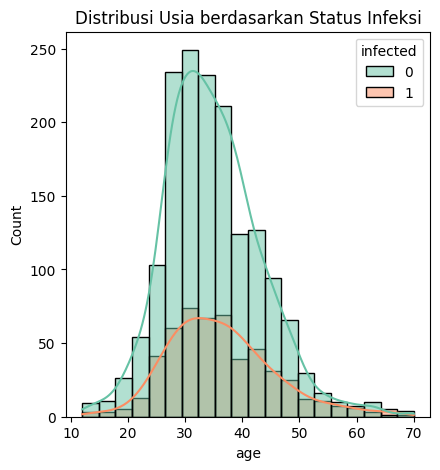

In [ ]:
# Distribusi usia
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
sns.histplot(data=df_new, x='age', bins=20, kde=True, hue='infected', palette='Set2')
plt.title('Distribusi Usia berdasarkan Status Infeksi')

Grafik ini menunjukkan distribusi usia pasien yang terinfeksi (infected = 1) dan tidak terinfeksi (infected = 0).

Interpretasi:

Mayoritas kasus, baik yang terinfeksi maupun tidak, berada dalam rentang usia 30–40 tahun.

Distribusi usia pasien terinfeksi cenderung sedikit lebih merata dibandingkan dengan pasien tidak terinfeksi yang lebih terpusat.

Ini menunjukkan bahwa usia tertentu memiliki tingkat risiko lebih tinggi, tetapi usia bukan satu-satunya faktor penentu infeksi.

Text(0.5, 1.0, 'Gender vs Status Infeksi')

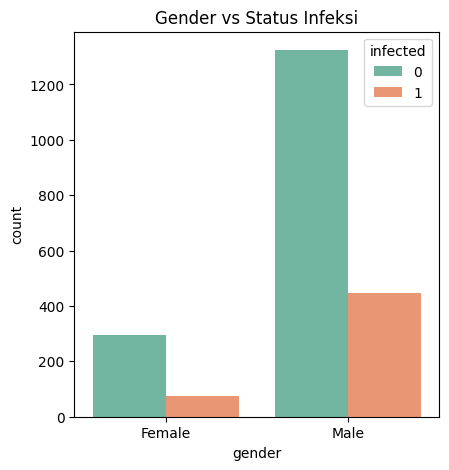

In [ ]:
# Gender vs infected
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 2)
sns.countplot(data=df_new, x='gender', hue='infected', palette='Set2')
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Gender vs Status Infeksi')

Grafik ini menunjukkan distribusi status infeksi berdasarkan gender.

Interpretasi:

Laki-laki memiliki jumlah infeksi yang jauh lebih tinggi dibandingkan perempuan.

Walaupun jumlah laki-laki memang lebih banyak dalam data, proporsi yang terinfeksi juga tampak jauh lebih besar pada laki-laki.

Ini mengindikasikan bahwa gender laki-laki lebih rentan terhadap infeksi dalam dataset ini.

Text(0.5, 1.0, 'Aktivitas Homoseksual vs Status Infeksi')

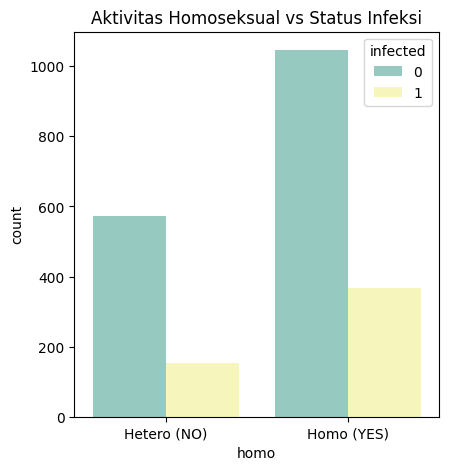

In [ ]:
# Homo vs infected
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 3)
sns.countplot(data=df_new, x='homo', hue='infected', palette='Set3')
plt.xticks([0, 1], ['Hetero (NO)', 'Homo (YES)'])
plt.title('Aktivitas Homoseksual vs Status Infeksi')

Grafik ini membandingkan infeksi berdasarkan apakah individu melakukan aktivitas homoseksual (homo = YES) atau tidak.

Interpretasi:

Kelompok homoseksual memiliki proporsi infeksi yang lebih tinggi dibandingkan kelompok heteroseksual.

Meskipun kelompok heteroseksual juga memiliki jumlah besar, proporsi infeksinya relatif lebih kecil.

Ini dapat menunjukkan bahwa aktivitas homoseksual dalam konteks dataset ini menjadi salah satu faktor risiko terhadap infeksi.

# 6. Analisis statistik hubungan antar variable

Grafik ini membandingkan infeksi berdasarkan apakah individu melakukan aktivitas homoseksual (homo = YES) atau tidak.

Interpretasi:

Kelompok homoseksual memiliki proporsi infeksi yang lebih tinggi dibandingkan kelompok heteroseksual.

Meskipun kelompok heteroseksual juga memiliki jumlah besar, proporsi infeksinya relatif lebih kecil.

Ini dapat menunjukkan bahwa aktivitas homoseksual dalam konteks dataset ini menjadi salah satu faktor risiko terhadap infeksi.

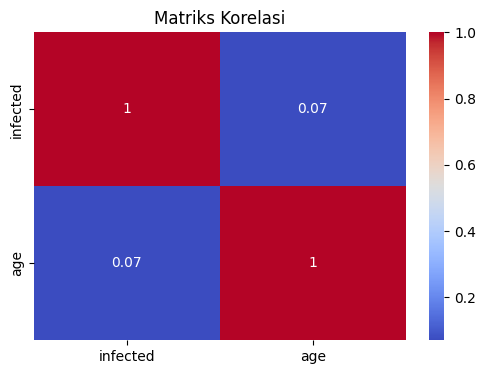

In [ ]:
# Korelasi Pearson antar numerik
plt.figure(figsize=(6,4))
sns.heatmap(df_new[['infected','age']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriks Korelasi')
plt.show()

Ini cuma buat kolom numerik jadinya aku ambil 'age' sama 'infected'

Korelasi 0.07 menunjukkan hubungan yang sangat lemah dan hampir tidak signifikan antara usia dan status infeksi.

Artinya, usia tidak memiliki pengaruh linier yang kuat terhadap kemungkinan seseorang terinfeksi dalam dataset ini.

Ini sejalan dengan temuan visualisasi histogram sebelumnya, di mana infeksi tersebar cukup merata di berbagai rentang usia, meskipun ada puncak di usia 30-an.

## Chi-Square Test
### Hubungan antar Variable Kategorik

Jika p < 0.05, artinya hubungan antar variabel signifikan.


### Gender vs Infected

In [ ]:
tab_gender = pd.crosstab(df_new['gender'], df_new['infected'])
chi2, p, dof, ex = chi2_contingency(tab_gender)
print(f"Chi-Square Gender vs Infected:\nChi2 = {chi2:.2f}, p-value = {p:.4f}")

Chi-Square Gender vs Infected:
Chi2 = 4.08, p-value = 0.0434


Karena 0.0434 < 0.05, maka terdapat hubungan antar variable signifikan

In [ ]:
ct_gender = pd.crosstab(df_new['gender'], df_new['infected'], normalize='index') * 100
ct_gender.columns = ['Not Infected (%)', 'Infected (%)']
print(ct_gender)

        Not Infected (%)  Infected (%)
gender                                
0              79.891304     20.108696
1              74.760023     25.239977


Karena p-value < 0.05, maka terdapat hubungan yang signifikan secara statistik antara jenis kelamin dan status infeksi AIDS.

Proporsi laki-laki yang terinfeksi lebih tinggi dibandingkan perempuan (25.24% vs 20.11%).

Ini menunjukkan bahwa laki-laki memiliki risiko infeksi AIDS yang lebih tinggi dibanding perempuan pada data ini.

### Homo vs Infected

In [ ]:
tab_homo = pd.crosstab(df_new['homo'], df_new['infected'])
chi2, p, dof, ex = chi2_contingency(tab_homo)
print(f"Chi-Square Homo vs Infected:\nChi2 = {chi2:.2f}, p-value = {p:.4f}")

Chi-Square Homo vs Infected:
Chi2 = 6.04, p-value = 0.0140


Karena 0.0140 < 0.05, maka terdapat hubungan antar variable signifikan

In [ ]:
ct_homo = pd.crosstab(df_new['homo'], df_new['infected'], normalize='index') * 100
ct_homo.columns = ['Not Infected (%)', 'Infected (%)']
print(ct_homo)

      Not Infected (%)  Infected (%)
homo                                
0            78.896552     21.103448
1            73.974540     26.025460


Karena p-value < 0.05, maka terdapat hubungan signifikan antara aktivitas homoseksual dan status infeksi AIDS.

Individu yang terlibat dalam aktivitas homoseksual memiliki proporsi infeksi lebih tinggi (~26%) dibandingkan yang tidak (~21%).

Hasil ini mendukung hipotesis bahwa aktivitas homoseksual dapat menjadi salah satu faktor risiko terhadap infeksi AIDS.

### Barplot untuk Proposi Terinfeksi

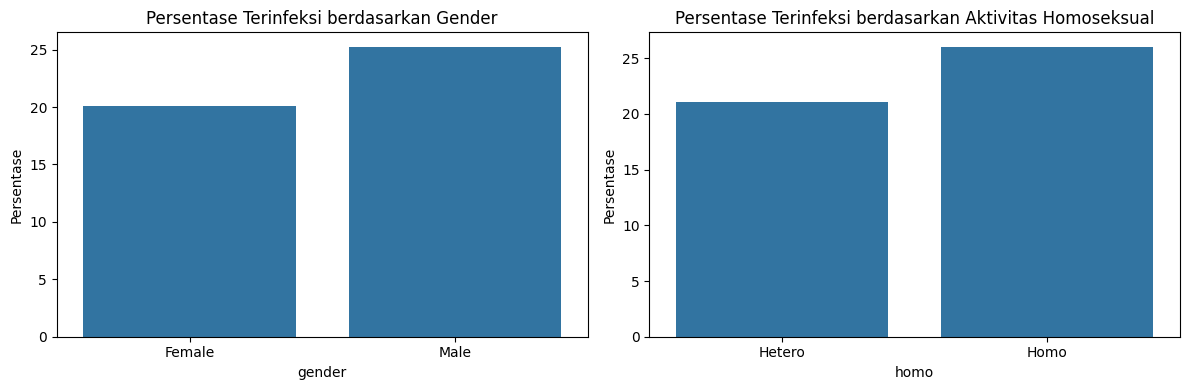

In [ ]:
# Buat proporsi dalam bentuk visual
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Gender
sns.barplot(x=ct_gender.index, y=ct_gender['Infected (%)'], ax=axs[0])
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['Female', 'Male'])
axs[0].set_title('Persentase Terinfeksi berdasarkan Gender')
axs[0].set_ylabel('Persentase')

# Homo
sns.barplot(x=ct_homo.index, y=ct_homo['Infected (%)'], ax=axs[1])
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['Hetero', 'Homo'])
axs[1].set_title('Persentase Terinfeksi berdasarkan Aktivitas Homoseksual')
axs[1].set_ylabel('Persentase')

plt.tight_layout()
plt.show()


### Gambar Kiri
Persentase Terinfeksi berdasarkan Gender
Grafik menunjukkan bahwa laki-laki memiliki tingkat infeksi AIDS yang lebih tinggi dibanding perempuan.
Male: sekitar 25% terinfeksi
Female: sekitar 20% terinfeksi

Interpretasi statistik (Chi-Square):
Hasil uji Chi-Square menunjukkan nilai p-value = 0.0434, artinya terdapat hubungan signifikan antara gender dan status infeksi AIDS (karena p < 0.05).

Kesimpulan: Gender berperan sebagai faktor risiko, di mana laki-laki memiliki peluang lebih besar untuk terinfeksi.

## Mann-Whitney
### Hubungan antar variable numerik

### Gambar Kanan
Persentase Terinfeksi berdasarkan Aktivitas Homoseksual
Grafik menunjukkan bahwa orang yang memiliki aktivitas homoseksual memiliki tingkat infeksi yang lebih tinggi.
Homoseksual: sekitar 26%
Heteroseksual: sekitar 21%

Interpretasi statistik (Chi-Square):
p-value = 0.0140 → signifikan secara statistik (p < 0.05)

Kesimpulan: Terdapat hubungan antara aktivitas homoseksual dan infeksi AIDS. Aktivitas homoseksual meningkatkan risiko terinfeksi AIDS.

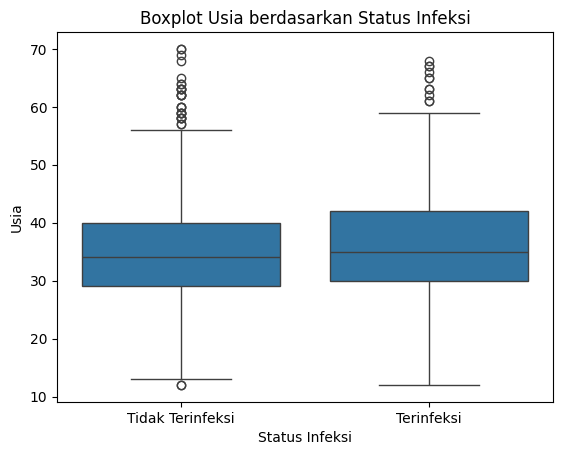

In [ ]:
sns.boxplot(x='infected', y='age', data=df_new)
plt.title('Boxplot Usia berdasarkan Status Infeksi')
plt.xticks([0, 1], ['Tidak Terinfeksi', 'Terinfeksi'])
plt.xlabel('Status Infeksi')
plt.ylabel('Usia')
plt.show()

Distribusi usia penderita AIDS (terinfeksi) cenderung sedikit lebih tinggi dibanding yang tidak terinfeksi.

Median usia penderita AIDS tampaknya sedikit lebih tua.

Terdapat outlier pada kedua kelompok, tetapi penyebaran usia relatif mirip.

Interpretasi statistik (Mann-Whitney U Test):

p-value = 0.0069 → signifikan secara statistik

Artinya, terdapat perbedaan usia yang signifikan antara kelompok yang terinfeksi dan yang tidak terinfeksi.

Kesimpulan: Usia memiliki hubungan dengan status infeksi, di mana kelompok usia tertentu (mungkin lebih tua) berisiko lebih tinggi.

In [ ]:
age_infected = df_new[df_new['infected'] == 1]['age']
age_notinfected = df_new[df_new['infected'] == 0]['age']

stat, p = mannwhitneyu(age_infected, age_notinfected)
print(f"Mann-Whitney U Test Age vs Infected:\nStat = {stat:.2f}, p-value = {p:.4f}")

Mann-Whitney U Test Age vs Infected:
Stat = 454583.50, p-value = 0.0069


Karena p-value < 0.05, maka terdapat perbedaan signifikan dalam distribusi usia antara individu yang terinfeksi dan tidak terinfeksi AIDS.

Artinya, usia pada saat pengukuran memiliki pengaruh terhadap kemungkinan seseorang terinfeksi.

Hasil ini mengindikasikan bahwa usia juga merupakan variabel penting yang harus dimasukkan dalam model prediksi.

# 7. MODELING

## Feature Selection and data spliting

In [ ]:
X = df_new.drop(labels='infected',axis=1)
y = df_new['infected']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 100)

print(f'Total: {len(X)}')
print(f'Total train sample: {len(X_train)}')
print(f'Total test sample: {len(X_test)}')

Total: 2139
Total train sample: 1497
Total test sample: 642


## Model Training

In [ ]:
# 1. Logistic Regression
model_lr = LogisticRegression(class_weight='balanced')
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.81      0.49      0.61       493
           1       0.27      0.61      0.37       149

    accuracy                           0.52       642
   macro avg       0.54      0.55      0.49       642
weighted avg       0.68      0.52      0.55       642

Confusion Matrix:
 [[241 252]
 [ 58  91]]
Accuracy: 0.5171339563862928


In [ ]:
# 5. Support Vector Machine
model_svc = SVC(class_weight = 'balanced')
model_svc.fit(X_train, y_train)
y_pred_svc = model_svc.predict(X_test)
print("=== Support Vector Machine ===")
print(classification_report(y_test, y_pred_svc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))
print("Accuracy:", accuracy_score(y_test, y_pred_svc))

=== Support Vector Machine ===
              precision    recall  f1-score   support

           0       0.78      0.67      0.72       493
           1       0.26      0.38      0.31       149

    accuracy                           0.60       642
   macro avg       0.52      0.52      0.51       642
weighted avg       0.66      0.60      0.63       642

Confusion Matrix:
 [[331 162]
 [ 93  56]]
Accuracy: 0.602803738317757


In [ ]:
# 6. Decision Tree
model_dt = DecisionTreeClassifier(class_weight = 'balanced')
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.78      0.48      0.60       493
           1       0.24      0.55      0.34       149

    accuracy                           0.50       642
   macro avg       0.51      0.52      0.47       642
weighted avg       0.66      0.50      0.54       642

Confusion Matrix:
 [[238 255]
 [ 67  82]]
Accuracy: 0.4984423676012461


In [ ]:
# 8. Random Forest
model_rf = RandomForestClassifier(class_weight = 'balanced')
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.76      0.53      0.62       493
           1       0.22      0.45      0.30       149

    accuracy                           0.51       642
   macro avg       0.49      0.49      0.46       642
weighted avg       0.63      0.51      0.55       642

Confusion Matrix:
 [[259 234]
 [ 82  67]]
Accuracy: 0.5077881619937694


In [ ]:
# 13. K-Nearest Neighbors
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
print("=== K-Nearest Neighbors ===")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       493
           1       0.29      0.11      0.16       149

    accuracy                           0.73       642
   macro avg       0.53      0.51      0.50       642
weighted avg       0.66      0.73      0.68       642

Confusion Matrix:
 [[453  40]
 [133  16]]
Accuracy: 0.7305295950155763


## Model Evaluation

In [ ]:
# ROC AUC Comparison
plt.figure(figsize=(12, 8))

models = {
    "Logistic Regression": model_lr,
    "SVC": model_svc,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "KNN": model_knn,
}

<Figure size 1200x800 with 0 Axes>

In [ ]:
# Initialize lists to collect metrics
evaluations = []

for name, model in models.items():
    # Obtain predicted labels
    y_pred = model.predict(X_test)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)  # sensitivity
    f1 = f1_score(y_test, y_pred)

    # Append results
    evaluations.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall (Sensitivity)": rec,
        "F1 Score": f1
    })

# Create DataFrame and display sorted by F1 Score
df_metrics = pd.DataFrame(evaluations)
df_metrics = df_metrics.set_index("Model").sort_values(by="F1 Score", ascending=False)

# Display the table
display(df_metrics)

,Accuracy,Precision,Recall (Sensitivity),F1 Score
Model,,,,
Logistic Regression,0.517134,0.265306,0.610738,0.369919
Decision Tree,0.498442,0.243323,0.550336,0.337449
SVC,0.602804,0.256881,0.375839,0.305177
Random Forest,0.507788,0.222591,0.449664,0.297778
KNN,0.730530,0.285714,0.107383,0.156098


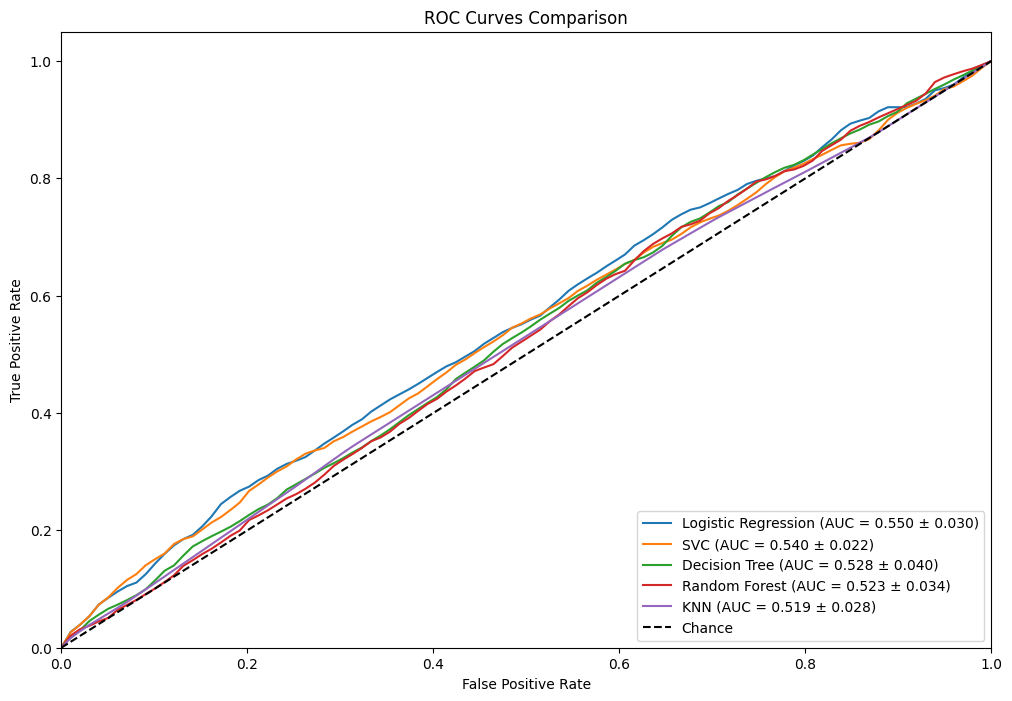

In [ ]:
plt.figure(figsize=(12, 8))
cv = StratifiedKFold(n_splits=5)

for name, model in models.items():
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    for train_index, test_index in cv.split(X, y):
        X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
        y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

        # Fit and predict
        model.fit(X_train_cv, y_train_cv)
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_cv)[:, 1]
        else:
            y_score = model.decision_function(X_test_cv)

        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test_cv, y_score)
        roc_auc = auc(fpr, tpr)

        # Interpolation for plotting
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)

    # Plot average ROC curve
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    plt.plot(mean_fpr, mean_tpr, label=f"{name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.show()

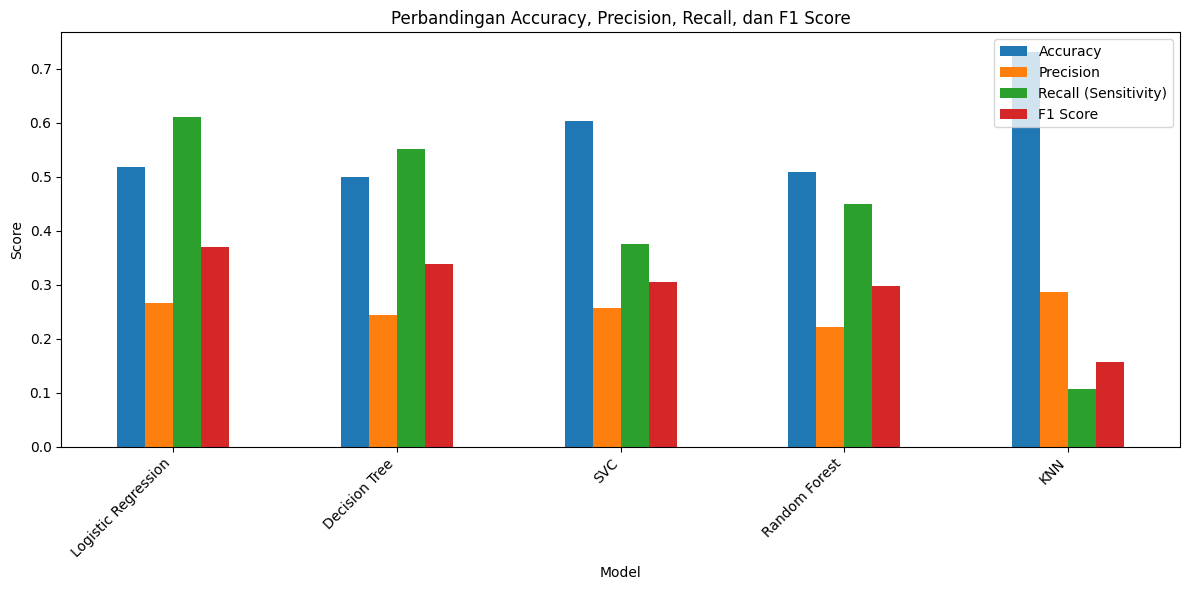

In [ ]:
ax = df_metrics.plot(kind='bar', figsize=(12, 6))  # figsize bisa disesuaikan
ax.set_ylabel('Score')
ax.set_title('Perbandingan Accuracy, Precision, Recall, dan F1 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<ipython-input-31-205709cd596c>:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


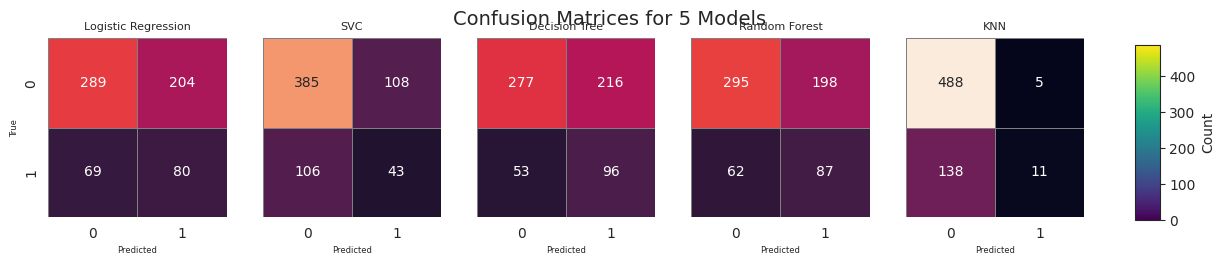

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Prepare
n_models = len(models)
cols = 5
rows = (n_models + cols - 1) // cols

# Compute global vmax
all_cms = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    all_cms.append(confusion_matrix(y_test, y_pred))
vmax = max(cm.max() for cm in all_cms)

sns.set_style("white")

fig, axes = plt.subplots(rows, cols,
                         figsize=(cols * 2.5, rows * 2.5),
                         sharex=True, sharey=True)
axes = axes.flatten()

for idx, ((name, model), cm) in enumerate(zip(models.items(), all_cms)):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cbar=False, vmin=0, vmax=vmax, square=True,
                linewidths=0.5, linecolor='gray')
    ax.set_title(name, fontsize=8)

    # figure out this subplot's row and column
    row = idx // cols
    col = idx % cols

    # only bottom row gets x-label
    if row == rows - 1:
        ax.set_xlabel("Predicted", fontsize=6)
    else:
        ax.set_xlabel("")

    # only first column gets y-label
    if col == 0:
        ax.set_ylabel("True", fontsize=6)
    else:
        ax.set_ylabel("")

# remove any unused axes
for j in range(n_models, len(axes)):
    fig.delaxes(axes[j])

# add a single colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=vmax))
norm.set_array([])
fig.colorbar(norm, cax=cbar_ax, label="Count")

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.suptitle("Confusion Matrices for {} Models".format(n_models),
             fontsize=14, y=0.99)

plt.show()


## Feature Selection

<ipython-input-32-7e760c3038d5>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(10), x='Importance', y='Feature', ax=axes[i], palette='viridis')
<ipython-input-32-7e760c3038d5>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(10), x='Importance', y='Feature', ax=axes[i], palette='viridis')
<ipython-input-32-7e760c3038d5>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(10), x='Importance', y='Feature', ax=axes[i], palette='viridis')
<ipython-input-32-7e760c3038d5>:39: FutureWarning: 

Passing `palet

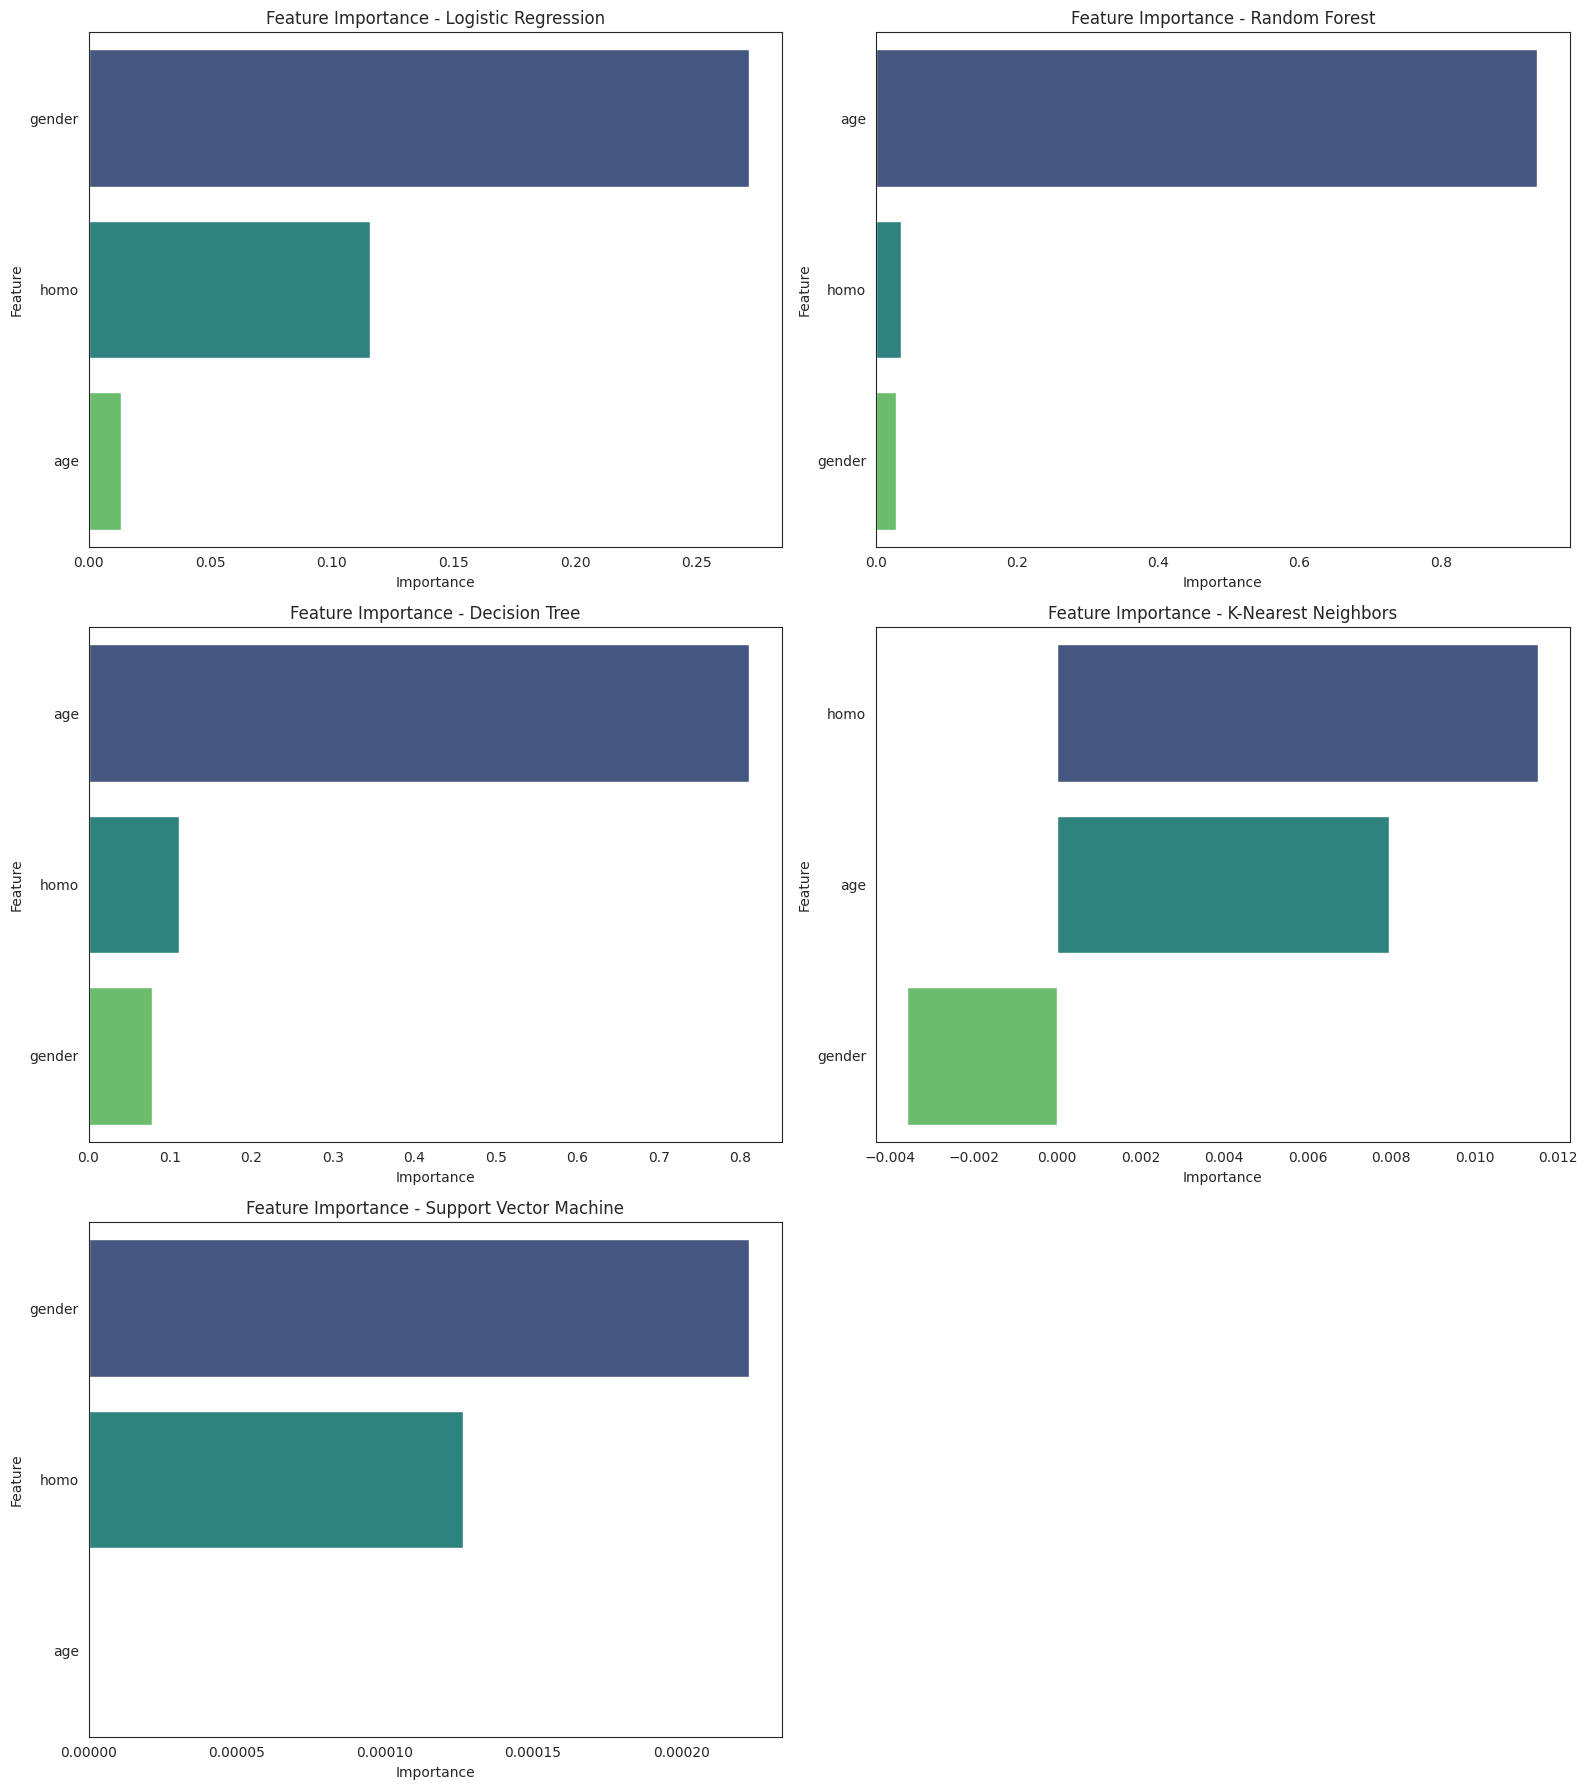

In [ ]:
from sklearn.inspection import permutation_importance

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=100),
    "Decision Tree": DecisionTreeClassifier(random_state=100),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(kernel="linear")
}


# Calculate feature importance
importance_results = {}

for name, model in models.items():
    if name in ["Logistic Regression", "K-Nearest Neighbors", "Support Vector Machine"]:
        model.fit(X_train, y_train)
        if name in ["Logistic Regression", "Support Vector Machine"]:
            importances = abs(model.coef_[0])
        else:
            result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
            importances = result.importances_mean
    else:
        model.fit(X_train, y_train)
        importances = model.feature_importances_

    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    importance_results[name] = importance_df

# Plotting feature importances
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, (name, df) in enumerate(importance_results.items()):
    sns.barplot(data=df.head(10), x='Importance', y='Feature', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Feature Importance - {name}')

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

🔹 1. Logistic Regression
gender memiliki pengaruh paling besar.

home juga memiliki pengaruh signifikan, tetapi lebih kecil dibanding gender.

age memiliki pengaruh paling kecil.

📌 Interpretasi: Model ini paling mengandalkan fitur gender untuk membuat prediksi.

🔹 2. Random Forest
age adalah fitur paling penting, jauh di atas dua fitur lainnya.

home dan gender memiliki pengaruh yang sangat kecil.

📌 Interpretasi: Model pohon acak menilai age sebagai faktor paling berpengaruh, mungkin karena ia non-linear dan dapat membagi rentang usia menjadi kategori yang relevan.

🔹 3. Decision Tree
Sama seperti Random Forest, age adalah fitur paling penting.

home dan gender memiliki kontribusi kecil.

📌 Interpretasi: Keputusan yang dibuat berdasarkan umur lebih informatif menurut pohon keputusan.



🔹 4. K-Nearest Neighbors (KNN)
home memiliki nilai penting tertinggi (positif).

gender memiliki nilai negatif yang relatif besar (mungkin menunjukkan kontribusi yang mengarah ke kelas tertentu).

age memiliki pengaruh yang kecil.

📌 Interpretasi: Model ini lebih sensitif terhadap fitur home, dan memperlakukan gender sebagai fitur yang mungkin mengaburkan hasil klasifikasi.

🔹 5. Support Vector Machine (SVM)
Semua fitur memiliki nilai importance yang sangat kecil (terlihat dari skala grafik).

Namun, gender dan home tetap sedikit lebih tinggi dari age.

📌 Interpretasi: Model SVM menganggap semua fitur tidak terlalu dominan, tapi sedikit lebih bergantung pada gender dan home.

✳️ Kesimpulan Umum:
age sangat penting untuk model berbasis pohon (Random Forest dan Decision Tree).

gender sangat penting dalam Logistic Regression dan SVM.

home memiliki kontribusi sedang dan lebih diperhatikan oleh KNN dan SVM.

Perbedaan importance ini mencerminkan bagaimana masing-masing model memproses data dan fitur: linear vs. non-linear, parametric vs. non-parametric.